# DATA DOWNLOAD

In [1]:
# Requirements:
!pip install arch
#

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm, probplot

# ----------------------------
# 1) Download Apple data
# ----------------------------
ticker = "AAPL"
start_date = "2020-01-01"
end_date   = "2025-12-31"


df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust= False,
)

# ---- FIX: flatten columns if MultiIndex ----
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep Close prices
df = df.dropna(subset=["Close"])
price = df["Close"].astype(float)

#  Log-returns

log_ret = np.log(price).diff().dropna()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.5 MB/s eta 0:00:00


## Volatility Estimate with GARCH



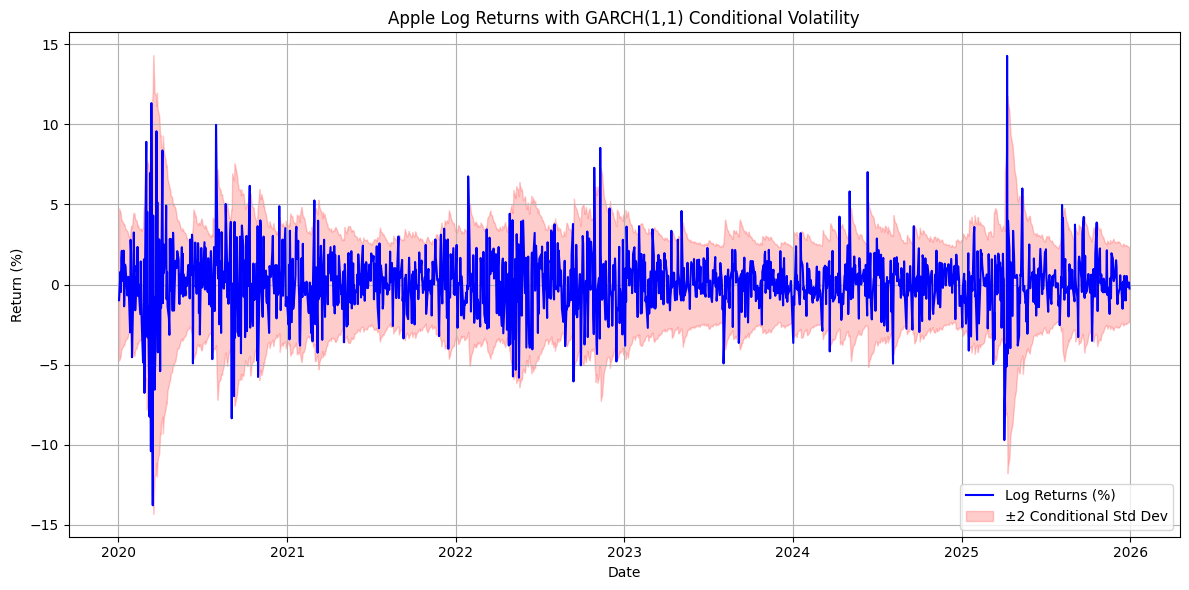

In [10]:
from arch import arch_model

# Convert to percentage returns for numerical stability
ret = 100 * log_ret

# Fit GARCH(1,1) with normal innovations
garch = arch_model(ret, vol='GARCH', p=1, q=1, mean='Constant', dist='normal')
garch_fit = garch.fit(disp='off')

# Conditional volatility (already in percentage units)
conditional_volatility = garch_fit.conditional_volatility

plt.figure(figsize=(12,6))

plt.plot(ret.index, ret, label='Log Returns (%)', color='blue')

upper_bound = 2 * conditional_volatility
lower_bound = -2 * conditional_volatility

plt.fill_between(
    ret.index,
    lower_bound,
    upper_bound,
    color='red',
    alpha=0.2,
    label='±2 Conditional Std Dev'
)

plt.title('Apple Log Returns with GARCH(1,1) Conditional Volatility')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("apple_returns_garch.png", dpi=300)
plt.show()
plt.close()

## Negative Log-Returns

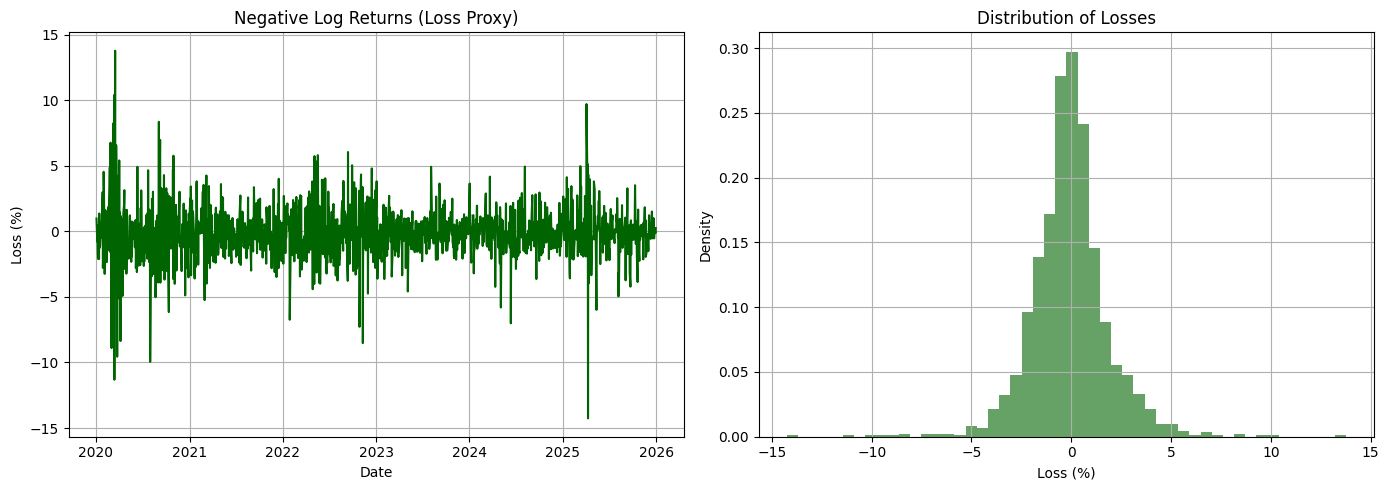

In [11]:
# --------------------------------------------
# Loss proxy (negative log-returns)
# --------------------------------------------
loss_proxy = -ret

fig, axs = plt.subplots(1, 2, figsize=(14,5))

# --------------------------------------------
# Left: Time series of losses
# --------------------------------------------
axs[0].plot(loss_proxy.index, loss_proxy, color='darkgreen')
axs[0].set_title("Negative Log Returns (Loss Proxy)")
axs[0].set_xlabel("Date")
axs[0].set_ylabel("Loss (%)")
axs[0].grid(True)

# --------------------------------------------
# Right: Histogram of losses
# --------------------------------------------
axs[1].hist(loss_proxy, bins=50, density=True, alpha=0.6, color='darkgreen')

axs[1].set_title("Distribution of Losses")
axs[1].set_xlabel("Loss (%)")
axs[1].set_ylabel("Density")
axs[1].grid(True)

plt.tight_layout()
plt.savefig("apple_losses_timeseries_hist.png", dpi=300)
plt.show()
plt.close()

# FUNCTION TO COMPUTE VAR

In [8]:
from scipy import stats
from scipy.stats import norm

# -------------------------------------------------------------------
# 1) VaR computation on losses (returns a DataFrame)
# -------------------------------------------------------------------
def compute_var_from_losses(losses_series, var_levels):
    """
    losses_series : pd.Series of positive losses (percent), e.g. 1.23 = 1.23% loss
    var_levels    : list of alpha levels (e.g. [0.95, 0.99])
    Returns DataFrame with Historical, Normal, T-dist VaR (all positive numbers = loss %)
    """
    x = losses_series.dropna().astype(float)

    # Fit Student-t to losses (loc, scale, df)
    try:
        df_t, loc_t, scale_t = stats.t.fit(x)
    except Exception:
        # fallback
        loc_t, scale_t = x.mean(), x.std(ddof=1)
        df_t = 5.0

    mu = x.mean()
    sigma = x.std(ddof=1)

    rows = {"VaR Level": [], "Historical": [], "Normal": [], "T-dist": []}

    for alpha in var_levels:
        # Historical VaR: empirical alpha-quantile of losses
        var_hist = np.percentile(x, 100 * alpha)

        # Parametric Normal on losses
        var_norm = mu + sigma * norm.ppf(alpha)

        # Parametric Student-t on losses
        var_t = stats.t.ppf(alpha, df_t, loc=loc_t, scale=scale_t)

        rows["VaR Level"].append(alpha)
        rows["Historical"].append(var_hist)
        rows["Normal"].append(var_norm)
        rows["T-dist"].append(var_t)

    df_var = pd.DataFrame(rows)
    return df_var


## VaR Computations for Apple

   VaR Level  Historical    Normal     T-dist
0     0.9000    2.112012  2.477190   1.985112
1     0.9250    2.572429  2.793127   2.340856
2     0.9500    3.119725  3.203742   2.866737
3     0.9750    3.914258  3.833918   3.862539
4     0.9900    5.106516  4.566634   5.447107
5     0.9950    6.654617  5.065561   6.922729
6     0.9990   10.046073  6.094294  11.693829
7     0.9995   11.232601  6.494855  14.548774
8     0.9999   13.263164  7.351773  23.974213


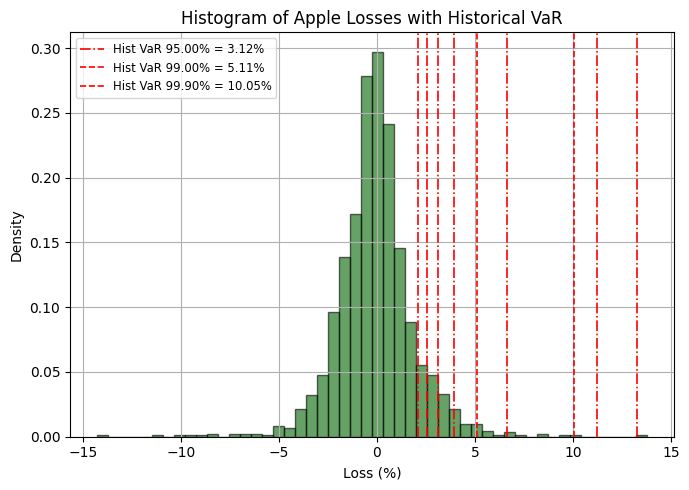

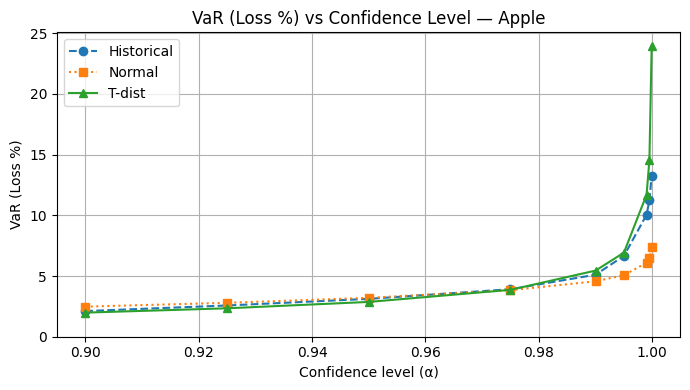

In [7]:
# --------------------------------------------------------
# 3) Usage: Apple only, with high VaR levels
# --------------------------------------------------------
var_levels = [0.90, 0.925, 0.95, 0.975, 0.99, 0.995, 0.999, 0.9995, 0.9999]

var_apple = compute_var_from_losses(loss_proxy, var_levels)
print(var_apple)

# --------------------------------------------------------
# 4B) Histogram of losses with historical VaR lines
# --------------------------------------------------------
fig, ax = plt.subplots(figsize=(7,5))

vals = loss_proxy
ax.hist(vals, bins=50, density=True, alpha=0.6, color='darkgreen', edgecolor='black')

for alpha, v in zip(var_apple["VaR Level"], var_apple["Historical"]):
    # choose which alphas to label to avoid legend clutter
    label = None
    if alpha in [0.95, 0.99, 0.999]:
        label = f'Hist VaR {alpha:.2%} = {v:.2f}%'
    ax.axvline(v,
               color='red',
               linestyle='--' if alpha in [0.99, 0.999] else '-.',
               linewidth=1.2,
               label=label)

ax.set_title("Histogram of Apple Losses with Historical VaR")
ax.set_xlabel("Loss (%)")
ax.set_ylabel("Density")
ax.grid(True)

# only show legend entries that have labels
handles, labels = ax.get_legend_handles_labels()
if labels:
    ax.legend(handles, labels, fontsize='small')

plt.tight_layout()
plt.savefig("apple_losses_hist_with_var_lines.png", dpi=300)
plt.show()
plt.close()

# --------------------------------------------------------
# 4C) VaR vs alpha comparison plot
# --------------------------------------------------------
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(var_apple["VaR Level"], var_apple["Historical"],
        label="Historical", linestyle='dashed', marker='o')
ax.plot(var_apple["VaR Level"], var_apple["Normal"],
        label="Normal", linestyle='dotted', marker='s')
ax.plot(var_apple["VaR Level"], var_apple["T-dist"],
        label="T-dist", linestyle='solid', marker='^')

ax.set_title("VaR (Loss %) vs Confidence Level — Apple")
ax.set_xlabel("Confidence level (α)")
ax.set_ylabel("VaR (Loss %)")
ax.set_ylim(bottom=0)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("apple_var_levels.png", dpi=300)
plt.show()
plt.close()

# FUNCTION TO COMPUTE ES

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

# --------------------------------------------------------
# Expected Shortfall computation on losses
# --------------------------------------------------------
def compute_es_from_losses(losses_series, es_levels):
    """
    losses_series : pd.Series of losses in percent (positive = bad days), e.g. 5.0 means 5% loss
    es_levels     : list of alpha levels (e.g. [0.95, 0.99])
    Returns DataFrame with Historical, Normal, T-dist ES (all positive numbers = loss %)
    """
    x = pd.Series(losses_series).dropna().astype(float)

    # Fit Student-t to losses: df, loc, scale
    try:
        df_t, loc_t, scale_t = stats.t.fit(x)
    except Exception:
        loc_t, scale_t = x.mean(), x.std(ddof=1)
        df_t = 5.0

    mu = x.mean()
    sigma = x.std(ddof=1)

    rows = {"ES Level": [], "Historical": [], "Normal": [], "T-dist": []}

    for alpha in es_levels:
        # -------- Historical ES --------
        var_hist = np.percentile(x, 100 * alpha)
        es_hist = x[x >= var_hist].mean()   # average of tail beyond VaR (right tail)

        # -------- Normal ES (loss model) --------
        # If L ~ N(mu, sigma^2), then ES_alpha = mu + sigma * phi(z_alpha)/(1-alpha)
        z = norm.ppf(alpha)
        es_norm = mu + sigma * (norm.pdf(z) / (1 - alpha))

        # -------- Student-t ES (loss model) --------
        # If L = loc + scale * T, T ~ t_df
        # VaR at alpha: q = t.ppf(alpha, df)
        # ES_alpha = loc + scale * [ (df + q^2)/((df-1)(1-alpha)) * t.pdf(q, df) ]
        q = stats.t.ppf(alpha, df_t)
        pdf_q = stats.t.pdf(q, df_t)
        if df_t > 1:
            es_t = loc_t + scale_t * ((df_t + q**2) / ((df_t - 1) * (1 - alpha))) * pdf_q
        else:
            es_t = np.nan  # ES undefined if df <= 1

        rows["ES Level"].append(alpha)
        rows["Historical"].append(es_hist)
        rows["Normal"].append(es_norm)
        rows["T-dist"].append(es_t)

    return pd.DataFrame(rows)



# ES FOR APPLE

   ES Level  Historical    Normal     T-dist
0    0.9000    3.592199  3.423986   3.498689
1    0.9250    4.010339  3.688812   3.947083
2    0.9500    4.583392  4.039401   4.628978
3    0.9750    5.671269  4.589542   5.962060
4    0.9900    7.343690  5.244319   8.145894
5    0.9950    8.968642  5.697755  10.214241
6    0.9990   12.084291  6.647971  16.988542
7    0.9995   13.770805  7.022525  21.067719
8    0.9999   13.770805  7.830666  34.576223


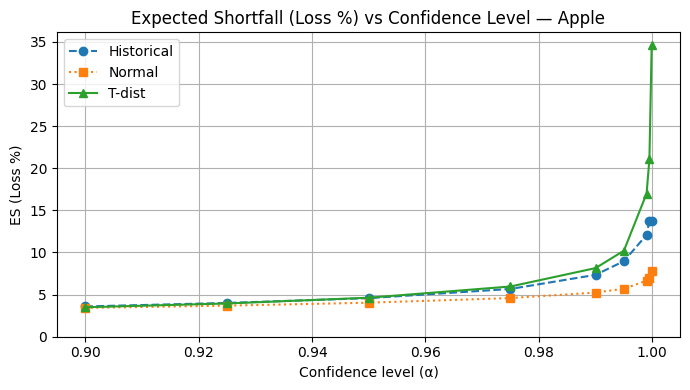

In [13]:

# --------------------------------------------------------
# Usage: Apple only (loss_proxy is your -ret, percent)
# --------------------------------------------------------
es_levels = [0.90, 0.925, 0.95, 0.975, 0.99, 0.995, 0.999, 0.9995, 0.9999]

es_apple = compute_es_from_losses(loss_proxy, es_levels)
print(es_apple)

# --------------------------------------------------------
# Plot ES vs confidence level — Apple
# --------------------------------------------------------
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(es_apple["ES Level"], es_apple["Historical"],
        label="Historical", linestyle='dashed', marker='o')
ax.plot(es_apple["ES Level"], es_apple["Normal"],
        label="Normal", linestyle='dotted', marker='s')
ax.plot(es_apple["ES Level"], es_apple["T-dist"],
        label="T-dist", linestyle='solid', marker='^')

ax.set_title("Expected Shortfall (Loss %) vs Confidence Level — Apple")
ax.set_xlabel("Confidence level (α)")
ax.set_ylabel("ES (Loss %)")
ax.set_ylim(bottom=0)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("apple_es_levels.png", dpi=300)
plt.show()
plt.close()

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 11.0 MB/s eta 0:00:00


# CODE FOR DYNAMIC VAR

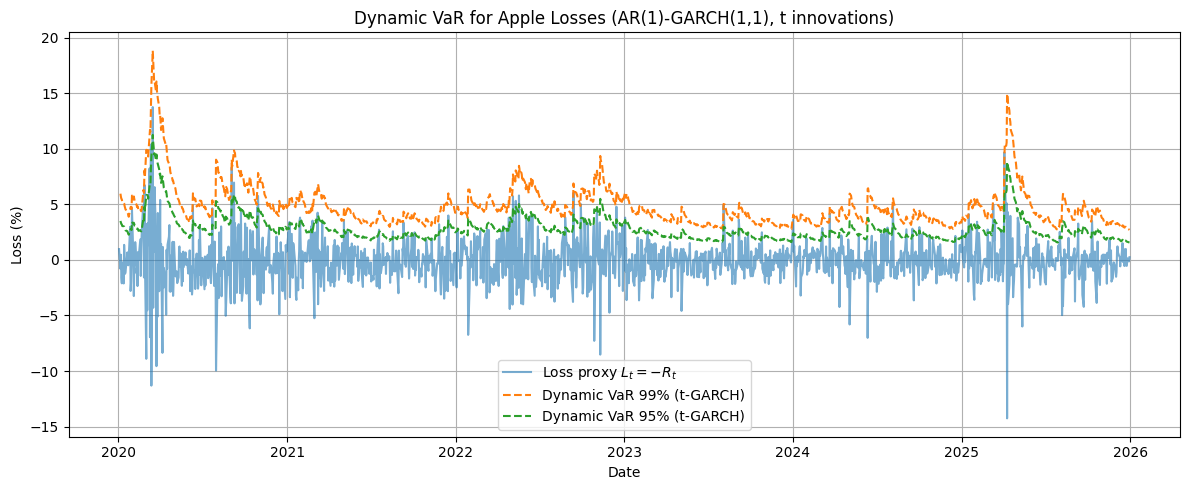

In [20]:

# ----------------------------
# Fit AR(1)-GARCH(1,1) with t innovations on RETURNS
# ----------------------------
model = arch_model(ret, vol="Garch", p=1, q=1, mean="AR", lags=1, dist="t")
res = model.fit(disp="off")

# One-step-ahead forecasts
fcst = res.forecast(start=0)
mu_r = fcst.mean.iloc[:, -1]                 # E[R_{t+1} | F_t] in percent
sigma_r = np.sqrt(fcst.variance.iloc[:, -1]) # SD of R_{t+1} | F_t in percent

# Student-t df
nu = res.params["nu"]

# Scale parameter for standardized t in arch: variance exists for nu>2
scale_lambda = sigma_r * np.sqrt((nu - 2) / nu)

# ----------------------------
# Dynamic VaR for LOSSES at levels alpha
# L = -R, so VaR_alpha(L) = - q_{1-alpha}(R)
# ----------------------------
alpha_95 = 0.95
alpha_99 = 0.99

# IMPORTANT: use the index from mu_r (or loss_proxy) consistently
idx = mu_r.index

q_ret_05 = stats.t.ppf(1 - alpha_95, df=nu, loc=mu_r.values, scale=scale_lambda.values)
q_ret_01 = stats.t.ppf(1 - alpha_99, df=nu, loc=mu_r.values, scale=scale_lambda.values)

# Convert to pandas Series with index
varL_95 = pd.Series(-q_ret_05, index=idx, name="VaR95")
varL_99 = pd.Series(-q_ret_01, index=idx, name="VaR99")

# Align loss series to the same index (safe)
loss_series = loss_proxy.reindex(idx)

# Plot
plt.figure(figsize=(12,5))
plt.plot(loss_series.index, loss_series, label="Loss proxy $L_t=-R_t$", alpha=0.6)
plt.plot(varL_99.index, varL_99, label="Dynamic VaR 99% (t-GARCH)", linestyle="dashed")
plt.plot(varL_95.index, varL_95, label="Dynamic VaR 95% (t-GARCH)", linestyle="dashed")

plt.xlabel("Date")
plt.ylabel("Loss (%)")
plt.title("Dynamic VaR for Apple Losses (AR(1)-GARCH(1,1), t innovations)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Vardyn_losses.png", dpi=300)
plt.show()
plt.close()

# DYNAMIC ES

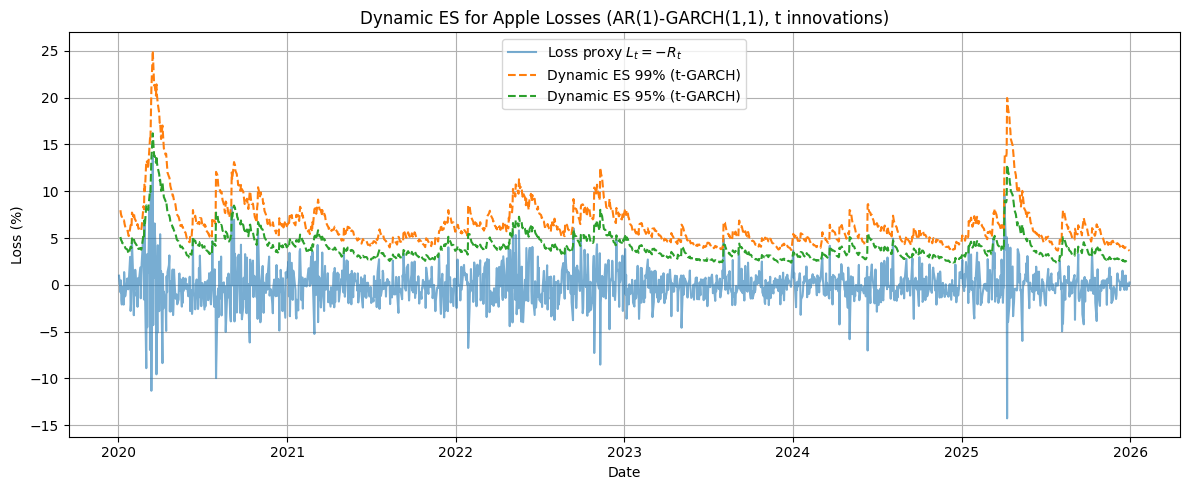

In [21]:
# ----------------------------
# Assume you already have:
# ret        = 100 * log_ret  (percent returns, pd.Series)
# loss_proxy = -ret           (percent losses, pd.Series)
# ----------------------------

# Fit AR(1)-GARCH(1,1) with t innovations on RETURNS
model = arch_model(ret, vol="Garch", p=1, q=1, mean="AR", lags=1, dist="t")
res = model.fit(disp="off")

# One-step-ahead forecasts
fcst = res.forecast(start=0)
mu_r = fcst.mean.iloc[:, -1]                 # conditional mean of returns (percent), pd.Series
sigma_r = np.sqrt(fcst.variance.iloc[:, -1]) # conditional sd of returns (percent), pd.Series

# Student-t df
nu = res.params["nu"]

# Scale parameter (arch uses standardized t; adjust to match sigma)
scale_lambda = sigma_r * np.sqrt((nu - 2) / nu)

# --------------------------------------------------------
# Dynamic ES for LOSSES at levels alpha
# compute left-tail ES for returns, then flip sign
# --------------------------------------------------------
alpha_95 = 0.95
alpha_99 = 0.99

idx = mu_r.index

def dynamic_es_losses_t(mu_series, scale_series, df, alpha):
    """
    Returns pd.Series of ES_alpha for LOSSES (positive),
    using Student-t with location mu and scale scale for RETURNS.
    """
    # standardized left-tail quantile for returns
    q = stats.t.ppf(1 - alpha, df=df)
    pdf_q = stats.t.pdf(q, df=df)

    # left-tail ES for standardized t:
    # E[T | T <= q] = - (pdf(q)/(1-alpha)) * (df + q^2)/(df - 1)
    if df <= 1:
        raise ValueError("ES undefined for t distribution with df <= 1.")

    es_std_left = - (pdf_q / (1 - alpha)) * (df + q**2) / (df - 1)

    # Transform back to RETURNS scale: ES_R = mu + scale * es_std_left
    es_returns = mu_series.values + scale_series.values * es_std_left

    # Convert to LOSSES: ES_L = -ES_R
    es_losses = -es_returns

    return pd.Series(es_losses, index=mu_series.index, name=f"ES{int(alpha*100)}")

esL_95 = dynamic_es_losses_t(mu_r, scale_lambda, nu, alpha_95)
esL_99 = dynamic_es_losses_t(mu_r, scale_lambda, nu, alpha_99)

# Align loss series to same index
loss_series = loss_proxy.reindex(idx)

# ----------------------------
# Plot: losses vs dynamic ES
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(loss_series.index, loss_series, label="Loss proxy $L_t=-R_t$", alpha=0.6)
plt.plot(esL_99.index, esL_99, label="Dynamic ES 99% (t-GARCH)", linestyle="dashed")
plt.plot(esL_95.index, esL_95, label="Dynamic ES 95% (t-GARCH)", linestyle="dashed")

plt.xlabel("Date")
plt.ylabel("Loss (%)")
plt.title("Dynamic ES for Apple Losses (AR(1)-GARCH(1,1), t innovations)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("ESdyn_losses.png", dpi=300)
plt.show()
plt.close()